<a href="https://colab.research.google.com/github/Nishanta04/Deep-Learning/blob/main/Nesterov_Accelerated_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset generated with X.shape: (100, 1) and y.shape: (100,)


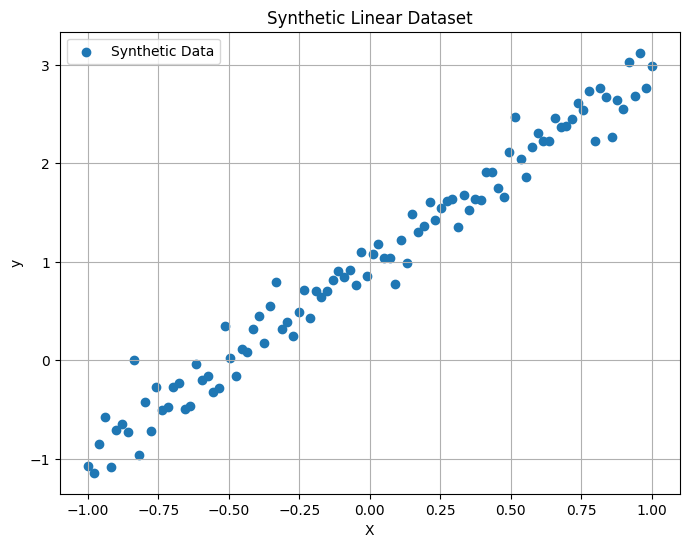

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

X = np.linspace(-1, 1, 100)
y = 2 * X + 1 + np.random.randn(*X.shape) * 0.2
X = X.reshape(-1, 1)

print("Dataset generated with X.shape: {} and y.shape: {}".format(X.shape, y.shape))
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Synthetic Data')
plt.title('Synthetic Linear Dataset')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(1,))
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
learning_rate = 0.01
momentum_rate = 0.9

optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(optimizer=optimizer, loss='mse')

In [ ]:
epochs = 50
epoch_predictions = []
epoch_losses = []

for epoch in range(epochs):
    history_epoch = model.fit(X, y, epochs=1, verbose=0)
    epoch_losses.append(history_epoch.history['loss'][0])
    epoch_predictions.append(model.predict(X))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML, display # Import display

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Left subplot: Loss over Epochs ---
ax1.set_title('Model Loss Over Epochs (with Momentum)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean Squared Error')
ax1.grid(True)
loss_line, = ax1.plot([], [], 'b-') # Line for loss
ax1.set_xlim(0, epochs - 1)
ax1.set_ylim(min(epoch_losses) * 0.9, max(epoch_losses) * 1.1) # Dynamic y-limit based on recorded losses

# --- Right subplot: Regression Line ---
ax2.scatter(X, y, label='Original Data', s=10)
ax2.set_title('Learned Regression Line vs. Original Data')
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.grid(True)
reg_line, = ax2.plot([], [], color='red', label='Learned Regression Line')
ax2.set_xlim(X.min(), X.max())
ax2.set_ylim(y.min() * 1.1, y.max() * 1.1)
ax2.legend()

def init():
    loss_line.set_data([], [])
    reg_line.set_data([], [])
    return loss_line, reg_line,

def update(frame):
    # Update loss plot
    loss_line.set_data(range(frame + 1), epoch_losses[:frame+1])

    # Update regression line plot
    reg_line.set_data(X, epoch_predictions[frame])

    fig.suptitle(f'Epoch {frame+1}/{epochs}', fontsize=16)

    return loss_line, reg_line,

ani = animation.FuncAnimation(fig, update, frames=epochs, init_func=init, blit=False, interval=100) # Set blit=False

# Display the animation
plt.close(fig) # Prevent the static plot from showing
display(HTML(ani.to_jshtml())) # Explicitly display the HTML

# Print learned weights and bias after all epochs
weights, bias = model.layers[0].get_weights()
print(f"Learned Weight (slope): {weights[0][0]:.4f}")
print(f"Learned Bias (intercept): {bias[0]:.4f}")

Learned Weight (slope): 1.9711
Learned Bias (intercept): 1.0011
